In [15]:
from pathlib import Path
import pandas as pd
from scipy.stats import skew, kurtosis
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from typing import Literal
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st
import statsmodels.api as sm

data_path = Path("/Users/zhengtaosun/Documents/bootcamp_Zhengtao_Sun/homework/stage9_hw/data/processed/S&P500_stock_hist_5y.parquet")
df = pd.read_parquet(data_path)

In [16]:
#clean data and feature
df = df[df['ticker'].isin(['NVDA'])]
df = df.reset_index(drop=True)
df["mom_5"] = df["adj close"]/df["adj close"].shift(5)-1
df["log_return"] = np.log(df["adj close"]).diff()
df["vol_std_5"] = df["log_return"].rolling(5).std()
df['next_excess_return'] = df['excess_return'].shift(-1) 
df = df.dropna(subset=["excess_return","mom_5","log_return","vol_std_5","next_excess_return"]).reset_index(drop=True)
df.head(10)

Price,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return,mom_5,log_return,vol_std_5,next_excess_return
0,2020-08-27,12.586762,12.62825,12.85000,12.56650,12.78150,317604000,NVDA,-0.011333,-0.013006,0.040133,-0.011397,0.020906,0.034405
1,2020-08-28,13.104554,13.14775,13.14800,12.64250,12.67500,537160000,NVDA,0.041138,0.034405,0.036602,0.040314,0.019453,0.019441
2,2020-08-31,13.330562,13.37450,13.57500,13.03775,13.18275,500840000,NVDA,0.017246,0.019441,0.051434,0.017099,0.019705,0.026168
3,2020-09-01,13.779715,13.82100,13.99375,13.43650,13.48000,511316000,NVDA,0.033693,0.026168,0.084324,0.033138,0.021437,0.022656
4,2020-09-02,14.303645,14.34650,14.72675,13.90000,14.70375,874012000,NVDA,0.038022,0.022656,0.123525,0.037317,0.021361,-0.057649
5,2020-09-03,12.976623,13.01550,13.88450,12.87875,13.82875,945128000,NVDA,-0.092775,-0.057649,0.030974,-0.097365,0.058528,-0.022062
6,2020-09-04,12.584794,12.62250,13.17500,11.70475,12.78375,1463684000,NVDA,-0.030195,-0.022062,-0.039663,-0.030660,0.056735,-0.028453
7,2020-09-08,11.877413,11.91300,12.55000,11.70425,11.73450,795728000,NVDA,-0.056209,-0.028453,-0.109009,-0.057851,0.058294,0.047177
8,2020-09-09,12.677018,12.71500,12.80925,12.23175,12.40000,736200000,NVDA,0.067322,0.047177,-0.080023,0.065152,0.067106,-0.014130
9,2020-09-10,12.274974,12.31175,13.06525,12.16700,12.98925,698684000,NVDA,-0.031714,-0.014130,-0.141829,-0.032228,0.059940,-0.012493


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1248 non-null   datetime64[ns]
 1   adj close           1248 non-null   float64       
 2   close               1248 non-null   float64       
 3   high                1248 non-null   float64       
 4   low                 1248 non-null   float64       
 5   open                1248 non-null   float64       
 6   volume              1248 non-null   int64         
 7   ticker              1248 non-null   object        
 8   daily_rtn           1248 non-null   float64       
 9   excess_return       1248 non-null   float64       
 10  mom_5               1248 non-null   float64       
 11  log_return          1248 non-null   float64       
 12  vol_std_5           1248 non-null   float64       
 13  next_excess_return  1248 non-null   float64     

## 2. Baseline model fit

In [18]:
X = df[["mom_5","log_return","vol_std_5"]]
y = df["next_excess_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.0117  RMSE=0.000635


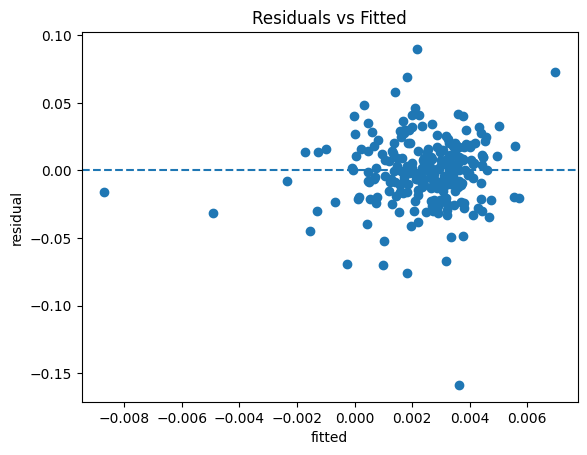

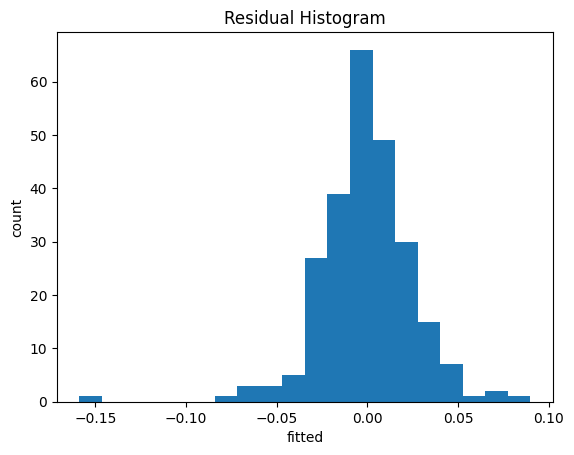

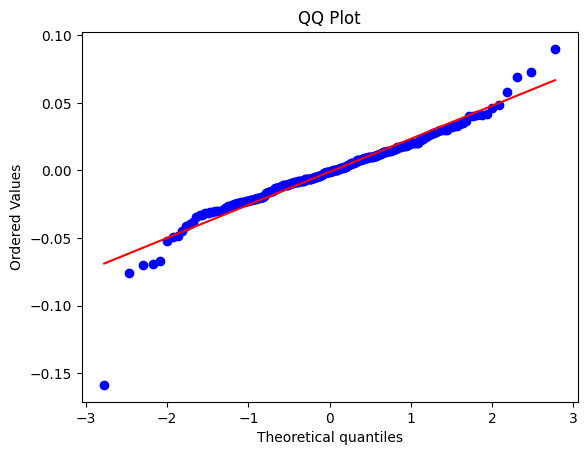

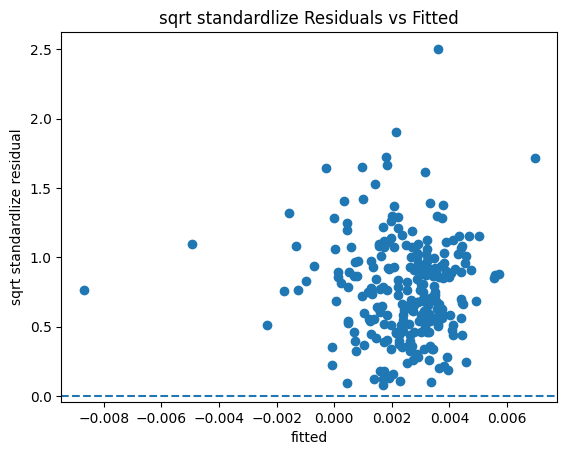

In [19]:
resid = y_test - y_pred
fitted = y_pred
sqrt_std_resid = np.sqrt(np.abs((resid-resid.mean()) / np.std(resid)))
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.xlabel("fitted"),plt.ylabel("residual");plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.xlabel("fitted"),plt.ylabel("count");plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()
plt.figure(); plt.scatter(fitted, sqrt_std_resid); plt.axhline(0, ls='--'); plt.title('sqrt standardlize Residuals vs Fitted'); plt.xlabel("fitted"),plt.ylabel("sqrt standardlize residual");plt.show()

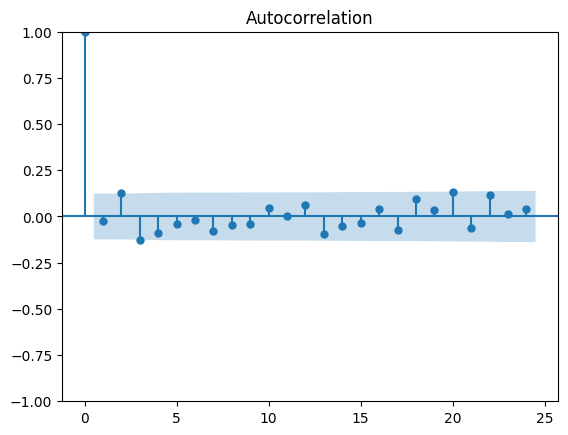

In [20]:
fig, ax = plt.subplots()
sm.graphics.tsa.plot_acf(resid,ax=ax)
plt.show()

## 3. Add a transform feature

In [21]:
df['log_return_sq'] = df['log_return']**2
X = df[["mom_5","log_return","vol_std_5","log_return_sq"]]
y = df["next_excess_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.0259  RMSE=0.000626


## 4. Interpretation
- **Linearity**: the points scatter around 0 in the Residual vs Fitted plot, and there is no obvious curve. Therefore, it is satisfied linearity. 
- **Homoscedasticity:** The graph indicates heteroscedasticity since the points are clustering but not flat spread. 
- **Normality:** The data is normality based on the Q-Q plot
- **Independence:** The data is indepence based on the autocorrelation graph because it randomly scatter 
- **Whether I trust this model:** I do not trust this linear regression model at this time since the R^2 is only 0.0259. I either need to investigate more relevant features, or using another model
- **Next step I would try:** Need to construct new features and using more data to train the model